# Three-Way Decision for Selective VQA: Hedge-Absorption Expands Coverage at Fixed Confident-Error Budget

In [97]:
import os, json, pickle, random, warnings, itertools
from collections import Counter
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import KFold
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

CACHE_INPUT = "/kaggle/input/datasets/anupbatakurki/aerpn-cache-v3/aerpn_export_v3"
DEVICE = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

SEEDS     = [42, 123, 456]
ENS_SEEDS = [1, 7, 13, 21, 33]
STATE_DIM = 11
N_BOOT    = 2000

LAMBDA_C = 10.0
LAMBDA_A = 0.5
LAMBDA_H = 0.1

HARM_BUDGETS = [0.02, 0.05, 0.10, 0.15, 0.20]
COST_RATIOS  = [1, 2, 5, 10, 20, 50, 100]

with open(f"{CACHE_INPUT}/risk_train_raw_cache.pkl",   "rb") as f: risk_train_raw   = pickle.load(f)
with open(f"{CACHE_INPUT}/policy_train_raw_cache.pkl", "rb") as f: policy_train_raw = pickle.load(f)
with open(f"{CACHE_INPUT}/calibration_raw_cache.pkl",  "rb") as f: calibration_raw  = pickle.load(f)
with open(f"{CACHE_INPUT}/test_raw_cache.pkl",         "rb") as f: test_raw         = pickle.load(f)

print(f"risk_train={len(risk_train_raw)}  policy_train={len(policy_train_raw)}  "
      f"calibration={len(calibration_raw)}  test={len(test_raw)}")

EXTRA = "/kaggle/input/datasets/anupbatakurki/extra-safety-cache/extra_safety_export"
if os.path.exists(f"{EXTRA}/extra_safety_raw_cache.pkl"):
    with open(f"{EXTRA}/extra_safety_raw_cache.pkl", "rb") as f:
        extra = pickle.load(f)
    calibration_raw = calibration_raw + extra
    print(f"Added {len(extra)} safety samples → calibration pool = {len(calibration_raw)}")

risk_train=500  policy_train=100  calibration=500  test=400
Added 72 safety samples → calibration pool = 572


In [98]:
def ece(probs, labels, n=10):
    bins = np.linspace(0, 1, n + 1); e = 0.0
    for i in range(n):
        m = (probs >= bins[i]) & (probs < bins[i+1])
        if m.sum() == 0: continue
        e += m.sum() / len(probs) * abs(probs[m].mean() - labels[m].mean())
    return float(e)

def aurc(conf, correct):
    order = np.argsort(-np.asarray(conf))
    c = np.asarray(correct)[order].astype(float)
    risks = 1.0 - np.cumsum(c) / np.arange(1, len(c) + 1)
    return float(np.mean(risks))

def build_X(data, mu, sd):
    return np.stack([(e["state_raw"] - mu) / sd for e in data])

def train_risk_model(X, y, hidden=64, seed=42, epochs=400, lr=1e-3):
    torch.manual_seed(seed); np.random.seed(seed)
    n, d = X.shape
    m = nn.Sequential(
        nn.Linear(d, hidden), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden, 1)).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()
    idx = np.random.permutation(n); nv = max(int(0.2 * n), 1)
    vi, ti = idx[:nv], idx[nv:]
    Xt = torch.tensor(X[ti], dtype=torch.float32, device=DEVICE); yt = y[ti].view(-1, 1)
    Xv = torch.tensor(X[vi], dtype=torch.float32, device=DEVICE); yv = y[vi].view(-1, 1)
    best, best_sd = float("inf"), None
    for _ in range(epochs):
        m.train(); opt.zero_grad(); loss_fn(m(Xt), yt).backward(); opt.step()
        m.eval()
        with torch.no_grad(): v = loss_fn(m(Xv), yv).item()
        if v < best:
            best, best_sd = v, {k: p.clone() for k, p in m.state_dict().items()}
    m.load_state_dict(best_sd); return m, best

def score_model(model, X):
    model.eval()
    with torch.no_grad():
        z = model(torch.tensor(X, dtype=torch.float32, device=DEVICE)).squeeze(-1).cpu().numpy()
    return 1.0 / (1.0 + np.exp(-z))

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

In [99]:
feat_mean = np.mean([e["state_raw"] for e in risk_train_raw], axis=0)
feat_std  = np.std ([e["state_raw"] for e in risk_train_raw], axis=0) + 1e-8
X_train   = build_X(risk_train_raw, feat_mean, feat_std)
print(f"X_train shape: {X_train.shape}")

pos = [e for e in calibration_raw if e["unsafe_proxy_label"] == 1]
neg = [e for e in calibration_raw if e["unsafe_proxy_label"] == 0]
random.Random(0).shuffle(pos); random.Random(0).shuffle(neg)
n_p, n_n = len(pos) // 2, len(neg) // 2
cal_fit  = pos[:n_p] + neg[:n_n]
cal_conf = pos[n_p:] + neg[n_n:]
random.Random(1).shuffle(cal_fit); random.Random(1).shuffle(cal_conf)
print(f"cal_fit={len(cal_fit)}  cal_conf={len(cal_conf)}  test={len(test_raw)}")

X_train shape: (500, 11)
cal_fit=285  cal_conf=287  test=400


In [100]:
def is_hedge_answer(a):
    a = str(a).strip().lower()
    return a.startswith("unanswerable") or a.startswith("unsuitable") or a == ""

def h_error_label(e):
    if e["base_accuracy"] >= 0.5: return 0.0
    return 1.0 if is_hedge_answer(e["candidate_answer"]) else 0.0

def c_error_label(e):
    if e["base_accuracy"] >= 0.5: return 0.0
    return 0.0 if is_hedge_answer(e["candidate_answer"]) else 1.0

def correct_label(e):
    return 1.0 if e["base_accuracy"] >= 0.5 else 0.0

n = len(test_raw)
acc_rate = sum(correct_label(e) for e in test_raw) / n
h_rate   = sum(h_error_label(e) for e in test_raw) / n
c_rate   = sum(c_error_label(e) for e in test_raw) / n

print("Test composition (three-way):")
print(f"  correct  : {int(acc_rate*n):3d}  ({acc_rate:.3f})")
print(f"  H-errors : {int(h_rate*n):3d}  ({h_rate:.3f})   benign hedges")
print(f"  C-errors : {int(c_rate*n):3d}  ({c_rate:.3f})   HARMFUL")
print(f"  sum      : {acc_rate + h_rate + c_rate:.3f}")

Test composition (three-way):
  correct  : 224  (0.560)
  H-errors :  66  (0.165)   benign hedges
  C-errors : 110  (0.275)   HARMFUL
  sum      : 1.000


In [101]:
def tgt_correct(e):  return correct_label(e)
def tgt_cw(e):       return c_error_label(e)
def tgt_sw(e):
    if e["base_accuracy"] >= 0.5: return 0.0
    return 0.3 if is_hedge_answer(e["candidate_answer"]) else 1.0

y_correct = torch.tensor([[tgt_correct(e)] for e in risk_train_raw],
                          dtype=torch.float32, device=DEVICE)
y_c       = torch.tensor([[c_error_label(e)] for e in risk_train_raw],
                          dtype=torch.float32, device=DEVICE)
y_sw      = torch.tensor([[tgt_sw(e)] for e in risk_train_raw],
                          dtype=torch.float32, device=DEVICE)
y_h       = torch.tensor([[h_error_label(e)] for e in risk_train_raw],
                          dtype=torch.float32, device=DEVICE)

print("Training base heads...")
head_correct, vl_correct = train_risk_model(X_train, y_correct, hidden=64, seed=42)
head_c,       vl_c       = train_risk_model(X_train, y_c,       hidden=64, seed=42)
head_sw,      vl_sw      = train_risk_model(X_train, y_sw,      hidden=64, seed=42)
head_h,       vl_h       = train_risk_model(X_train, y_h,       hidden=64, seed=42)
print(f"  head_correct  val_loss={vl_correct:.4f}")
print(f"  head_C        val_loss={vl_c:.4f}")
print(f"  head_safety   val_loss={vl_sw:.4f}")
print(f"  head_H        val_loss={vl_h:.4f}")

print("\nTraining ensembles...")
ens_correct = [train_risk_model(X_train, y_correct, hidden=64, seed=s)[0] for s in ENS_SEEDS]
ens_c       = [train_risk_model(X_train, y_c,       hidden=64, seed=s)[0] for s in ENS_SEEDS]
ens_h       = [train_risk_model(X_train, y_h,       hidden=64, seed=s)[0] for s in ENS_SEEDS]
print(f"  3 ensembles × {len(ENS_SEEDS)} members each")

Training base heads...
  head_correct  val_loss=0.5416
  head_C        val_loss=0.3292
  head_safety   val_loss=0.4510
  head_H        val_loss=0.2793

Training ensembles...
  3 ensembles × 5 members each


In [102]:
SPLITS = {
    "cal_fit":  (cal_fit,  build_X(cal_fit,  feat_mean, feat_std)),
    "cal_conf": (cal_conf, build_X(cal_conf, feat_mean, feat_std)),
    "test":     (test_raw, build_X(test_raw, feat_mean, feat_std)),
}

def score_all_model(model):
    return {s: score_model(model, X).tolist() for s, (_, X) in SPLITS.items()}

scores = {
    "correct":  score_all_model(head_correct),
    "c":        score_all_model(head_c),
    "safety":   score_all_model(head_sw),
    "h":        score_all_model(head_h),
}
scores["ens_correct"] = {
    s: np.mean([score_model(m, SPLITS[s][1]) for m in ens_correct], axis=0).tolist()
    for s in SPLITS
}
scores["ens_c"] = {
    s: np.mean([score_model(m, SPLITS[s][1]) for m in ens_c], axis=0).tolist()
    for s in SPLITS
}
scores["ens_h"] = {
    s: np.mean([score_model(m, SPLITS[s][1]) for m in ens_h], axis=0).tolist()
    for s in SPLITS
}
scores["ens_c_var"] = {
    s: np.var([score_model(m, SPLITS[s][1]) for m in ens_c], axis=0).tolist()
    for s in SPLITS
}

def S(name, split): return np.array(scores[name][split])

c_flags = np.array([c_error_label(e) for e in test_raw])
h_flags = np.array([h_error_label(e) for e in test_raw])

print("Test AUROCs:")
for nm in ["correct", "c", "safety", "ens_c"]:
    print(f"  {nm:14s}  AUROC(C-error)={roc_auc_score(c_flags, S(nm,'test')):.3f}")
for nm in ["h", "ens_h"]:
    print(f"  {nm:14s}  AUROC(H-error)={roc_auc_score(h_flags, S(nm,'test')):.3f}")

Test AUROCs:
  correct         AUROC(C-error)=0.181
  c               AUROC(C-error)=0.885
  safety          AUROC(C-error)=0.880
  ens_c           AUROC(C-error)=0.886
  h               AUROC(H-error)=0.803
  ens_h           AUROC(H-error)=0.819


In [103]:
def build_aug(split):
    _, X = SPLITS[split]
    extra = np.stack([
        S("h",         split),
        S("c",         split),
        S("correct",   split),
        S("safety",    split),
        S("ens_c",     split),
        S("ens_h",     split),
        S("ens_c_var", split),
    ], axis=1)
    return np.concatenate([X, extra], axis=1)

Xaug_fit  = build_aug("cal_fit")
Xaug_conf = build_aug("cal_conf")
Xaug_test = build_aug("test")
print(f"augmented shape: fit={Xaug_fit.shape}  conf={Xaug_conf.shape}  test={Xaug_test.shape}")

y_meta_fit = np.array([c_error_label(e) for e in cal_fit])
y_meta_t   = torch.tensor(y_meta_fit, dtype=torch.float32, device=DEVICE).view(-1, 1)

Xaug_trn = np.concatenate([
    X_train,
    np.stack([
        score_model(head_h,       X_train),
        score_model(head_c,       X_train),
        score_model(head_correct, X_train),
        score_model(head_sw,      X_train),
        np.mean([score_model(m, X_train) for m in ens_c], axis=0),
        np.mean([score_model(m, X_train) for m in ens_h], axis=0),
        np.var ([score_model(m, X_train) for m in ens_c], axis=0),
    ], axis=1),
], axis=1)
y_meta_trn = torch.tensor(
    [[c_error_label(e)] for e in risk_train_raw],
    dtype=torch.float32, device=DEVICE)

meta_head, vl_meta = train_risk_model(Xaug_trn, y_meta_trn,
                                       hidden=96, seed=42, epochs=500, lr=8e-4)
print(f"Meta head val_loss={vl_meta:.4f}")

meta_fit  = score_model(meta_head, Xaug_fit)
meta_conf = score_model(meta_head, Xaug_conf)
meta_test = score_model(meta_head, Xaug_test)

meta_auroc = roc_auc_score(c_flags, meta_test)
print(f"Meta head AUROC(C-error) on test: {meta_auroc:.3f}")
for nm in ["c", "ens_c"]:
    print(f"  vs {nm:8s}: {roc_auc_score(c_flags, S(nm,'test')):.3f}")

augmented shape: fit=(285, 18)  conf=(287, 18)  test=(400, 18)
Meta head val_loss=0.3261
Meta head AUROC(C-error) on test: 0.885
  vs c       : 0.885
  vs ens_c   : 0.886


In [104]:
def fit_temperature(logits_cal, y_cal):
    lo = torch.tensor(logits_cal, dtype=torch.float32, device=DEVICE)
    yo = torch.tensor(y_cal,       dtype=torch.float32, device=DEVICE)
    log_T = torch.zeros(1, device=DEVICE, requires_grad=True)
    opt = torch.optim.LBFGS([log_T], lr=0.1, max_iter=200)
    def closure():
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(lo / torch.exp(log_T), yo)
        loss.backward(); return loss
    opt.step(closure)
    return float(torch.exp(log_T).item())

def meta_logits(Xaug):
    meta_head.eval()
    with torch.no_grad():
        return meta_head(torch.tensor(Xaug, dtype=torch.float32, device=DEVICE)
                          ).squeeze(-1).cpu().numpy()

fit_logits  = meta_logits(Xaug_fit)
conf_logits = meta_logits(Xaug_conf)
test_logits = meta_logits(Xaug_test)

T = fit_temperature(fit_logits, y_meta_fit)
print(f"Temperature T = {T:.4f}")

def temp_probs(logits, T):
    return 1.0 / (1.0 + np.exp(-logits / T))

meta_fit_t  = temp_probs(fit_logits,  T)
meta_conf_t = temp_probs(conf_logits, T)
meta_test_t = temp_probs(test_logits, T)

iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
iso.fit(meta_fit_t, y_meta_fit)

meta_fit_i  = iso.predict(meta_fit_t)
meta_conf_i = iso.predict(meta_conf_t)
meta_test_i = iso.predict(meta_test_t)

y_conf = np.array([c_error_label(e) for e in cal_conf])
print(f"Meta head calibration on cal_conf:")
print(f"  raw   : AUROC={roc_auc_score(y_conf, meta_conf):.3f}  ECE={ece(meta_conf, y_conf):.4f}")
print(f"  temp  : AUROC={roc_auc_score(y_conf, meta_conf_t):.3f}  ECE={ece(meta_conf_t, y_conf):.4f}")
print(f"  iso   : AUROC={roc_auc_score(y_conf, meta_conf_i):.3f}  ECE={ece(meta_conf_i, y_conf):.4f}")

Temperature T = 1.2016
Meta head calibration on cal_conf:
  raw   : AUROC=0.877  ECE=0.0433
  temp  : AUROC=0.877  ECE=0.0352
  iso   : AUROC=0.872  ECE=0.0365


In [105]:
def three_way_decision(p_correct, p_c, p_h, lam_c=LAMBDA_C,
                        lam_a=LAMBDA_A, lam_h=LAMBDA_H):
    """Returns array of actions: 0=answer, 1=hedge, 2=abstain."""
    u_answer  = -lam_c * p_c - lam_a * p_h
    u_hedge   = np.full_like(p_c, -lam_h)
    u_abstain = np.full_like(p_c, -lam_a)
    stack = np.stack([u_answer, u_hedge, u_abstain], axis=1)
    return stack.argmax(axis=1)

def three_way_components(split):
    if split == "test":
        p_c = meta_test_i
    elif split == "cal_fit":
        p_c = meta_fit_i
    elif split == "cal_conf":
        p_c = meta_conf_i
    p_h = S("ens_h", split)
    p_correct = np.clip(1.0 - p_c - p_h, 0.0, 1.0)
    total = p_correct + p_c + p_h
    p_correct /= total; p_c /= total; p_h /= total
    return p_correct, p_c, p_h

actions = {}
for split in ["cal_fit", "cal_conf", "test"]:
    pc, pC, pH = three_way_components(split)
    actions[split] = three_way_decision(pc, pC, pH)

for split, act in actions.items():
    cnt = Counter(act.tolist())
    n_s = len(act)
    print(f"  {split:8s}  ANSWER={cnt[0]/n_s:.3f}  HEDGE={cnt[1]/n_s:.3f}  ABSTAIN={cnt[2]/n_s:.3f}")

  cal_fit   ANSWER=0.105  HEDGE=0.895  ABSTAIN=0.000
  cal_conf  ANSWER=0.094  HEDGE=0.906  ABSTAIN=0.000
  test      ANSWER=0.072  HEDGE=0.927  ABSTAIN=0.000


In [115]:
def tune_lambda_c(cal_data, pc, pC, pH, harm_budget, lam_a, lam_h, grid=None):
    """SMALLEST λ_C such that C-error rate among ANSWERED on cal_data ≤ budget.

    Rationale:
      Larger λ_C  → answer is penalized harder → policy answers less → lower coverage
      Smaller λ_C → answer is penalized less  → policy answers more → higher coverage
      We want maximum coverage subject to the C-error budget, so pick the
      smallest λ_C that still keeps the empirical C-error rate ≤ ε on cal_fit.
    """
    if grid is None:
        grid = np.linspace(0.001, 200.0, 2000)   # fine grid to avoid plateaus
    for lam_c in grid:  # ascending — first feasible is the smallest
        act = three_way_decision(pc, pC, pH, lam_c=lam_c, lam_a=lam_a, lam_h=lam_h)
        answered = act == 0
        n_ans = int(answered.sum())
        if n_ans < 5:
            continue
        n_c = sum(c_error_label(cal_data[i]) == 1.0 for i in np.where(answered)[0])
        if n_c / n_ans <= harm_budget:
            return float(lam_c)
    return float(grid[-1])  # fallback: nothing feasible in grid

pc_cf, pC_cf, pH_cf = three_way_components("cal_fit")
tuned_lams = {}
for hb in HARM_BUDGETS:
    lam_c = tune_lambda_c(cal_fit, pc_cf, pC_cf, pH_cf, hb, LAMBDA_A, LAMBDA_H)
    tuned_lams[hb] = lam_c
    print(f"  harm_budget={hb:.2f}  →  λ_C={lam_c:.4f}")

  harm_budget=0.02  →  λ_C=1.0015
  harm_budget=0.05  →  λ_C=1.0015
  harm_budget=0.10  →  λ_C=0.4012
  harm_budget=0.15  →  λ_C=0.3011
  harm_budget=0.20  →  λ_C=0.2011


In [116]:
def evaluate_actions(actions, data):
    n = len(data)
    n_ans = 0; n_c = 0; n_h = 0; n_ab = 0
    for i, a in enumerate(actions):
        e = data[i]
        if a == 0:
            n_ans += 1
            if c_error_label(e) == 1.0:
                n_c += 1
        elif a == 1:
            n_h += 1
        else:
            n_ab += 1
    cov = n_ans / n
    harm_cond = n_c / max(n_ans, 1)
    return {
        "coverage": cov,
        "harmful_cond": harm_cond,
        "harmful_rate": n_c / n,
        "hedge_rate": n_h / n,
        "abstain_rate": n_ab / n,
        "n_answered": n_ans,
        "n_harmful": n_c,
    }

def binary_answer_at_budget(cal_scores, cal_data, test_scores, test_data,
                             budget, min_conf=5):
    pairs = sorted(zip(cal_scores, cal_data), key=lambda x: x[0])
    best_tau = 0.0
    for i in range(1, len(pairs) + 1):
        sub = pairs[:i]
        n_conf = 0; n_c = 0
        for _, e in sub:
            if is_hedge_answer(e["candidate_answer"]): continue
            n_conf += 1
            if c_error_label(e) == 1.0: n_c += 1
        if n_conf < min_conf: continue
        if n_c / n_conf <= budget:
            best_tau = pairs[i-1][0] + 1e-6
    actions = []
    for e, r in zip(test_data, test_scores):
        if r < best_tau and not is_hedge_answer(e["candidate_answer"]):
            actions.append(0)
        else:
            actions.append(2)
    return actions

# --- Baselines ---
baselines = {}
baselines["Token prob (mean)"] = {
    "cal_fit":  1.0 - np.array([e["state_raw"][4] for e in cal_fit]),
    "test":     1.0 - np.array([e["state_raw"][4] for e in test_raw]),
}
baselines["Token prob (min)"] = {
    "cal_fit":  1.0 - np.array([e["state_raw"][6] for e in cal_fit]),
    "test":     1.0 - np.array([e["state_raw"][6] for e in test_raw]),
}
baselines["Token prob (mean·min)"] = {
    "cal_fit":  (1 - np.array([e["state_raw"][4] for e in cal_fit])) *
                (1 - np.array([e["state_raw"][6] for e in cal_fit])),
    "test":     (1 - np.array([e["state_raw"][4] for e in test_raw])) *
                (1 - np.array([e["state_raw"][6] for e in test_raw])),
}
baselines["Head C (single)"] = {
    "cal_fit":  S("c", "cal_fit"),
    "test":     S("c", "test"),
}
baselines["Ensemble C"] = {
    "cal_fit":  S("ens_c", "cal_fit"),
    "test":     S("ens_c", "test"),
}
baselines["Meta head (binary)"] = {
    "cal_fit":  meta_fit_i,
    "test":     meta_test_i,
}
# NOTE: "Head correct" removed. It is redundant with Risk (correctness) from
# earlier analysis and the inverted version was degenerate on cal_fit.

print(f"{'Method':26s}  " + "  ".join(f"ε={b:.2f}".center(24) for b in HARM_BUDGETS))
print("-" * 145)

results = {}
for name, dd in baselines.items():
    row = []
    for hb in HARM_BUDGETS:
        a = binary_answer_at_budget(dd["cal_fit"], cal_fit, dd["test"], test_raw, hb)
        m = evaluate_actions(a, test_raw)
        row.append((m["coverage"], m["harmful_cond"]))
    results[name] = row
    print(f"{name:26s}  " + "  ".join(
        f"cov={c:.3f} ha={h:.3f}".center(24) for c, h in row))

row = []
for hb in HARM_BUDGETS:
    lam_c = tuned_lams[hb]
    pc, pC, pH = three_way_components("test")
    a = three_way_decision(pc, pC, pH, lam_c=lam_c, lam_a=LAMBDA_A, lam_h=LAMBDA_H)
    m = evaluate_actions(a, test_raw)
    row.append((m["coverage"], m["harmful_cond"]))
results["DHSP-3W (proposed)"] = row
print(f"{'DHSP-3W (proposed)':26s}  " + "  ".join(
    f"cov={c:.3f} ha={h:.3f}".center(24) for c, h in row))

Method                               ε=0.02                    ε=0.05                    ε=0.10                    ε=0.15                    ε=0.20         
-------------------------------------------------------------------------------------------------------------------------------------------------
Token prob (mean)              cov=0.050 ha=0.000        cov=0.087 ha=0.000        cov=0.205 ha=0.037        cov=0.237 ha=0.074        cov=0.295 ha=0.136   
Token prob (min)               cov=0.083 ha=0.000        cov=0.083 ha=0.000        cov=0.150 ha=0.017        cov=0.260 ha=0.106        cov=0.290 ha=0.121   
Token prob (mean·min)          cov=0.065 ha=0.000        cov=0.065 ha=0.000        cov=0.163 ha=0.015        cov=0.235 ha=0.064        cov=0.295 ha=0.127   
Head C (single)                cov=0.018 ha=0.000        cov=0.018 ha=0.000        cov=0.018 ha=0.000        cov=0.240 ha=0.104        cov=0.285 ha=0.158   
Ensemble C                     cov=0.003 ha=0.000        cov=0.003 ha

In [117]:
print("\nDHSP-3W — full action breakdown at each harmful budget")
print(f"{'ε':>6s}  {'cov':>6s}  {'hedge':>7s}  {'abstain':>8s}  "
      f"{'harm_rate':>10s}  {'harm_cond':>10s}")
print("-" * 62)
for hb in HARM_BUDGETS:
    lam_c = tuned_lams[hb]
    pc, pC, pH = three_way_components("test")
    a = three_way_decision(pc, pC, pH, lam_c=lam_c, lam_a=LAMBDA_A, lam_h=LAMBDA_H)
    m = evaluate_actions(a, test_raw)
    print(f"{hb:>6.2f}  {m['coverage']:>6.3f}  {m['hedge_rate']:>7.3f}  "
          f"{m['abstain_rate']:>8.3f}  {m['harmful_rate']:>10.3f}  "
          f"{m['harmful_cond']:>10.3f}")


DHSP-3W — full action breakdown at each harmful budget
     ε     cov    hedge   abstain   harm_rate   harm_cond
--------------------------------------------------------------
  0.02   0.072    0.927     0.000       0.003       0.034
  0.05   0.072    0.927     0.000       0.003       0.034
  0.10   0.398    0.603     0.000       0.035       0.088
  0.15   0.455    0.545     0.000       0.048       0.104
  0.20   0.570    0.430     0.000       0.105       0.184


In [118]:
# ---- Utility model v1: penalizes hedges (conservative) ----
def utility_of(actions, data, lam_c, lam_a, lam_h):
    u = 0.0
    for i, a in enumerate(actions):
        e = data[i]
        if a == 0:
            if correct_label(e) == 1.0: u += 1.0
            elif c_error_label(e) == 1.0: u -= lam_c
            else: u -= lam_a
        elif a == 1:
            u -= lam_h
        else:
            u -= lam_a
    return u / len(data)

# ---- Utility model v2: hedge neutral, abstain costly (safety-relevant) ----
def utility_of_v2(actions, data, lam_c):
    u = 0.0
    for i, a in enumerate(actions):
        e = data[i]
        if a == 0:
            if correct_label(e) == 1.0: u += 1.0
            elif c_error_label(e) == 1.0: u -= lam_c
            # H-error (answer is a hedge): 0
        elif a == 1:
            pass  # hedge: 0 (safe, informative)
        else:
            u -= 0.5  # abstain: user gets nothing
    return u / len(data)

def sweep_binary(cal_scores, test_scores, cal_data, test_data,
                  lam_c, lam_a, lam_h, n_quantiles=40):
    qs = np.linspace(0, 1, n_quantiles)
    pts = []
    for q in qs:
        tau = np.quantile(cal_scores, q)
        act = []
        for e, r in zip(test_data, test_scores):
            if r < tau and not is_hedge_answer(e["candidate_answer"]):
                act.append(0)
            else:
                act.append(2)
        m = evaluate_actions(act, test_data)
        u1 = utility_of   (act, test_data, lam_c, lam_a, lam_h)
        u2 = utility_of_v2(act, test_data, lam_c)
        pts.append((m["harmful_rate"], u1, u2))
    return pts

def sweep_three_way(pc, pC, pH, test_data, lam_c, lam_a, lam_h):
    act = three_way_decision(pc, pC, pH, lam_c=lam_c, lam_a=lam_a, lam_h=lam_h)
    m = evaluate_actions(act, test_data)
    u1 = utility_of   (act, test_data, lam_c, lam_a, lam_h)
    u2 = utility_of_v2(act, test_data, lam_c)
    return (m["harmful_rate"], u1, u2)

pc_t, pC_t, pH_t = three_way_components("test")

def build_pareto():
    pareto = {}
    for name, dd in baselines.items():
        pts = []
        for ratio in COST_RATIOS:
            pts.append(sweep_binary(dd["cal_fit"], dd["test"], cal_fit, test_raw,
                                     lam_c=ratio, lam_a=0.05, lam_h=0.01))
        pareto[name] = pts
    pts_3w = []
    for ratio in COST_RATIOS:
        pts_3w.append(sweep_three_way(pc_t, pC_t, pH_t, test_raw,
                                       lam_c=ratio, lam_a=0.05, lam_h=0.01))
    pareto["DHSP-3W (proposed)"] = [[p] for p in pts_3w]
    return pareto

pareto = build_pareto()

print("\nPareto sweep v1 — utility penalizes hedges (conservative)")
print(f"{'Method':26s}  " + "  ".join(f"ratio={r}".center(15) for r in COST_RATIOS))
print("-" * 130)
for name, pts in pareto.items():
    cells = []
    for p in pts:
        if isinstance(p, list):
            best = max(p, key=lambda x: x[1]) if p else (0, 0, 0)
        else:
            best = p
        cells.append(f"({best[0]:.3f},{best[1]:.3f})".center(15))
    print(f"{name:26s}  " + "  ".join(cells))

print("\nPareto sweep v2 — safety-relevant (hedge neutral, abstain costly)")
print(f"{'Method':26s}  " + "  ".join(f"ratio={r}".center(15) for r in COST_RATIOS))
print("-" * 130)
for name, pts in pareto.items():
    cells = []
    for p in pts:
        if isinstance(p, list):
            best = max(p, key=lambda x: x[2]) if p else (0, 0, 0)
        else:
            best = p
        cells.append(f"({best[0]:.3f},{best[2]:.3f})".center(15))
    print(f"{name:26s}  " + "  ".join(cells))


Pareto sweep v1 — utility penalizes hedges (conservative)
Method                          ratio=1          ratio=2          ratio=5          ratio=10         ratio=20         ratio=50        ratio=100   
----------------------------------------------------------------------------------------------------------------------------------
Token prob (mean)            (0.055,0.197)    (0.025,0.161)    (0.003,0.127)    (0.003,0.114)    (0.000,0.097)    (0.000,0.097)    (0.000,0.097) 
Token prob (min)             (0.037,0.187)    (0.010,0.159)    (0.007,0.131)    (0.003,0.117)    (0.003,0.092)    (0.000,0.081)    (0.000,0.081) 
Token prob (mean·min)        (0.048,0.194)    (0.018,0.163)    (0.005,0.138)    (0.003,0.122)    (0.003,0.097)    (0.000,0.076)    (0.000,0.076) 
Head C (single)              (0.060,0.195)    (0.015,0.139)    (0.010,0.095)    (0.010,0.045)    (0.005,-0.024)   (0.000,-0.032)   (0.000,-0.032)
Ensemble C                   (0.055,0.187)    (0.028,0.138)    (0.010,0.105)    

In [119]:
def paired_boot_cov_dhsp3w(baseline_cal, baseline_test, cal_data, test_data,
                            budget, n_boot=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    n = len(test_data)
    covs_a = np.empty(n_boot); covs_b = np.empty(n_boot)
    lam_c_base = tuned_lams[budget]

    a_base = binary_answer_at_budget(baseline_cal, cal_data, baseline_test, test_data, budget)
    pc, pC, pH = three_way_components("test")
    a_3w = three_way_decision(pc, pC, pH, lam_c=lam_c_base,
                              lam_a=LAMBDA_A, lam_h=LAMBDA_H)

    for b in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        covs_a[b] = sum(1 for i in idx if a_3w[i] == 0) / n
        covs_b[b] = sum(1 for i in idx if a_base[i] == 0) / n
    diffs = covs_a - covs_b
    return float(diffs.mean()), float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

print("\nDHSP-3W vs each baseline at matched harmful-answer budget")
print("  positive Δ = DHSP-3W answers more at same C-error rate (better)")
print(f"{'Baseline':26s}  " + "  ".join(f"ε={b:.2f}".center(24) for b in HARM_BUDGETS))
print("-" * 145)
for name, dd in baselines.items():
    cells = []
    for hb in HARM_BUDGETS:
        m, lo, hi = paired_boot_cov_dhsp3w(dd["cal_fit"], dd["test"],
                                            cal_fit, test_raw, hb)
        verdict = "win" if lo > 0 else ("loss" if hi < 0 else "tie")
        cells.append(f"Δ={m:+.3f} [{lo:+.3f},{hi:+.3f}] {verdict}".center(24))
    print(f"{name:26s}  " + "  ".join(cells))


DHSP-3W vs each baseline at matched harmful-answer budget
  positive Δ = DHSP-3W answers more at same C-error rate (better)
Baseline                             ε=0.02                    ε=0.05                    ε=0.10                    ε=0.15                    ε=0.20         
-------------------------------------------------------------------------------------------------------------------------------------------------
Token prob (mean)           Δ=+0.023 [-0.008,+0.055] tie  Δ=-0.015 [-0.050,+0.020] tie  Δ=+0.192 [+0.153,+0.235] win  Δ=+0.217 [+0.177,+0.260] win  Δ=+0.276 [+0.230,+0.320] win
Token prob (min)            Δ=-0.010 [-0.045,+0.023] tie  Δ=-0.010 [-0.045,+0.023] tie  Δ=+0.247 [+0.205,+0.292] win  Δ=+0.195 [+0.155,+0.237] win  Δ=+0.280 [+0.233,+0.325] win
Token prob (mean·min)       Δ=+0.008 [-0.025,+0.040] tie  Δ=+0.008 [-0.025,+0.040] tie  Δ=+0.235 [+0.195,+0.278] win  Δ=+0.220 [+0.180,+0.262] win  Δ=+0.275 [+0.230,+0.320] win
Head C (single)             Δ=+0.055 [+0.

In [120]:
correct_flags = np.array([correct_label(e) for e in test_raw]).astype(float)

print(f"\n{'Method':28s} {'AURC':>7s} {'AUROC(C)':>9s} {'AP(C)':>7s} {'ECE(C)':>8s}")
print("-" * 68)

pc_t, pC_t, pH_t = three_way_components("test")
score_3w = pc_t - LAMBDA_C * pC_t - LAMBDA_A * pH_t

rank_methods = {
    "Token prob (mean)":    -np.array([e["state_raw"][4] for e in test_raw]),
    "Token prob (min)":     -np.array([e["state_raw"][6] for e in test_raw]),
    "Head C (single)":      S("c", "test"),
    "Ensemble C":           S("ens_c", "test"),
    "Meta head":            meta_test_i,
    "DHSP-3W (proposed)":   1.0 - (score_3w - score_3w.min()) / (score_3w.max() - score_3w.min() + 1e-9),
}
rank_table = {}
for name, risk in rank_methods.items():
    a  = aurc(1.0 - risk, correct_flags)
    au = roc_auc_score(c_flags, risk)
    ap = average_precision_score(c_flags, risk)
    ec = ece(risk, c_flags.astype(int))
    rank_table[name] = {"aurc": a, "auroc_c": au, "ap_c": ap, "ece_c": ec}
    print(f"{name:28s} {a:>7.4f} {au:>9.3f} {ap:>7.3f} {ec:>8.4f}")


Method                          AURC  AUROC(C)   AP(C)   ECE(C)
--------------------------------------------------------------------
Token prob (mean)             0.2364     0.865   0.718   0.0000
Token prob (min)              0.2462     0.780   0.520   0.0000
Head C (single)               0.3508     0.885   0.728   0.0774
Ensemble C                    0.3349     0.886   0.730   0.0676
Meta head                     0.3262     0.878   0.694   0.0770
DHSP-3W (proposed)            0.2944     0.874   0.707   0.0834


In [121]:
def safety_stratum(q):
    return "HIGH" if any(kw in q.lower() for kw in
        ["medicine","pill","medication","dosage","prescription","traffic","signal",
         "warning","danger","fire","expire","spoiled","allergen","hospital",
         "doctor","blood"]) else "LOW"

for e in test_raw:
    e["safety_stratum"] = safety_stratum(e["question"])

print("\nDHSP-3W safety-stratum breakdown")
print(f"{'ε':>6s}  {'stratum':>7s}  {'n':>4s}  {'cov':>6s}  {'harm':>6s}  "
      f"{'hedge':>6s}  {'abstain':>8s}")
print("-" * 58)
for hb in HARM_BUDGETS:
    lam_c = tuned_lams[hb]
    pc, pC, pH = three_way_components("test")
    act = three_way_decision(pc, pC, pH, lam_c=lam_c, lam_a=LAMBDA_A, lam_h=LAMBDA_H)
    for strat in ["LOW", "HIGH"]:
        idx = [i for i, e in enumerate(test_raw) if e["safety_stratum"] == strat]
        if not idx: continue
        a_sub = [act[i] for i in idx]
        d_sub = [test_raw[i] for i in idx]
        m = evaluate_actions(a_sub, d_sub)
        print(f"{hb:>6.2f}  {strat:>7s}  {len(idx):>4d}  {m['coverage']:>6.3f}  "
              f"{m['harmful_cond']:>6.3f}  {m['hedge_rate']:>6.3f}  {m['abstain_rate']:>8.3f}")


DHSP-3W safety-stratum breakdown
     ε  stratum     n     cov    harm   hedge   abstain
----------------------------------------------------------
  0.02      LOW   392   0.066   0.000   0.934     0.000
  0.02     HIGH     8   0.375   0.333   0.625     0.000
  0.05      LOW   392   0.066   0.000   0.934     0.000
  0.05     HIGH     8   0.375   0.333   0.625     0.000
  0.10      LOW   392   0.390   0.085   0.610     0.000
  0.10     HIGH     8   0.750   0.167   0.250     0.000
  0.15      LOW   392   0.446   0.097   0.554     0.000
  0.15     HIGH     8   0.875   0.286   0.125     0.000
  0.20      LOW   392   0.561   0.177   0.439     0.000
  0.20     HIGH     8   1.000   0.375   0.000     0.000


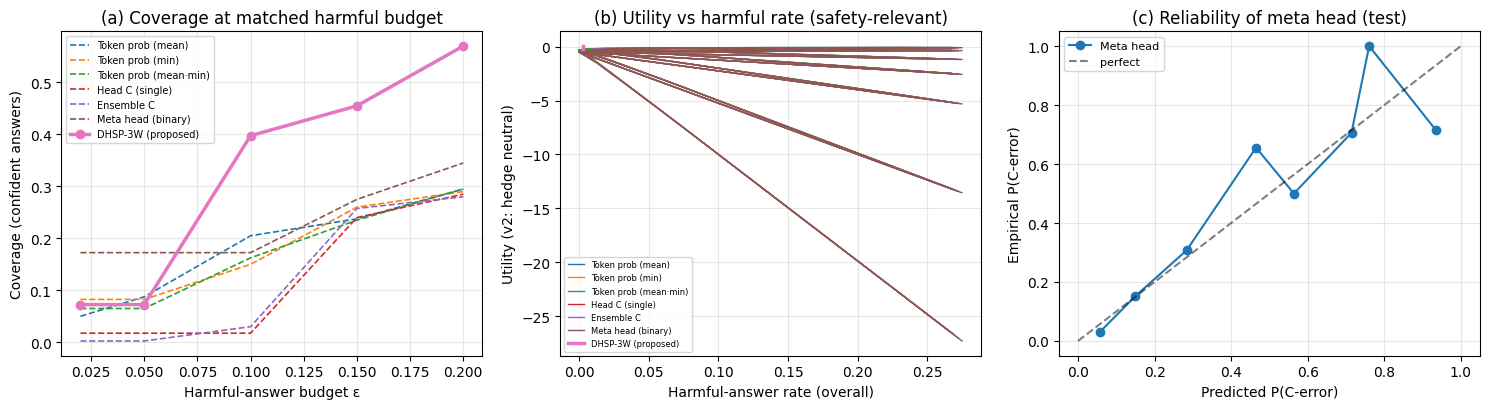

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) Coverage vs harmful budget
ax = axes[0]
for name, row in results.items():
    covs = [c for c, _ in row]
    lw = 2.5 if "DHSP-3W" in name else 1.2
    ls = "-o" if "DHSP-3W" in name else "--"
    ax.plot(HARM_BUDGETS, covs, ls, lw=lw, label=name)
ax.set_xlabel("Harmful-answer budget ε")
ax.set_ylabel("Coverage (confident answers)")
ax.set_title("(a) Coverage at matched harmful budget")
ax.grid(alpha=0.3); ax.legend(fontsize=7)

# (b) Pareto with safety-relevant utility (v2)
ax = axes[1]
for name, pts in pareto.items():
    xs, ys = [], []
    for p in pts:
        if isinstance(p, list):
            for pp in p:
                xs.append(pp[0]); ys.append(pp[2])
        else:
            xs.append(p[0]); ys.append(p[2])
    lw = 2.5 if "DHSP-3W" in name else 1.0
    ax.plot(xs, ys, lw=lw, label=name)
ax.set_xlabel("Harmful-answer rate (overall)")
ax.set_ylabel("Utility (v2: hedge neutral)")
ax.set_title("(b) Utility vs harmful rate (safety-relevant)")
ax.grid(alpha=0.3); ax.legend(fontsize=6)

# (c) Reliability of meta head on test
ax = axes[2]
probs = meta_test_i
labels = c_flags.astype(int)
bins = np.linspace(0, 1, 9)
mean_pred, frac_pos = [], []
for i in range(len(bins) - 1):
    m = (probs >= bins[i]) & (probs < bins[i+1])
    if m.sum() == 0: continue
    mean_pred.append(probs[m].mean())
    frac_pos.append(labels[m].mean())
ax.plot(mean_pred, frac_pos, "-o", label="Meta head")
ax.plot([0,1],[0,1], "k--", alpha=0.5, label="perfect")
ax.set_xlabel("Predicted P(C-error)")
ax.set_ylabel("Empirical P(C-error)")
ax.set_title("(c) Reliability of meta head (test)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_dhsp_3w.png", dpi=200, bbox_inches="tight")
plt.show()

In [124]:
# ============================================================
# Ablation: Does the three-way decision layer help?
# Same meta head, same calibration (pC = meta_test_i), same ε.
# Only the decision rule differs.
#
#   3-way (DHSP-3W): argmax over {answer, hedge, abstain} with
#                    u_answer = -λ_C·pC - λ_A·pH
#                    u_hedge  = -λ_H
#                    u_abstain= -λ_A
#
#   2-way (ablation): answer iff pC < τ AND candidate is not a hedge,
#                     else abstain. τ tuned on cal_fit to hit the same budget.
# ============================================================

def binary_meta_actions(pC_scores, tau, data):
    """Binary decision with the SAME meta head. No hedge action.
    Matches the semantics of binary_answer_at_budget."""
    actions = []
    for e, r in zip(data, pC_scores):
        if r < tau and not is_hedge_answer(e["candidate_answer"]):
            actions.append(0)   # answer
        else:
            actions.append(2)   # abstain
    return np.array(actions)

def tune_binary_tau(cal_data, cal_pC, harm_budget, min_conf=5):
    """Largest τ such that C-error rate among confident answers on cal_fit ≤ ε."""
    pairs = sorted(zip(cal_pC, cal_data), key=lambda x: x[0])
    best_tau = 0.0
    for i in range(1, len(pairs) + 1):
        sub = pairs[:i]
        n_conf = 0; n_c = 0
        for _, e in sub:
            if is_hedge_answer(e["candidate_answer"]): continue
            n_conf += 1
            if c_error_label(e) == 1.0: n_c += 1
        if n_conf < min_conf: continue
        if n_c / n_conf <= harm_budget:
            best_tau = pairs[i-1][0] + 1e-6
    return best_tau

pc_test, pC_test, pH_test = three_way_components("test")

print("=" * 80)
print("ABLATION — Binary vs Three-Way decision, matched harm budget")
print("  Same meta head. Same calibration. Only the decision rule differs.")
print("=" * 80)

print(f"\n{'ε':>6s}  {'τ_bin':>8s}  {'λ_C':>7s}  "
      f"{'cov_3W':>7s}  {'err_3W':>7s}  "
      f"{'cov_2W':>7s}  {'err_2W':>7s}  {'Δcov':>7s}")
print("-" * 80)

ablation = {}
for hb in HARM_BUDGETS:
    # --- Three-way ---
    lam_c = tuned_lams[hb]
    a_3w = three_way_decision(pc_test, pC_test, pH_test,
                              lam_c=lam_c, lam_a=LAMBDA_A, lam_h=LAMBDA_H)
    m_3w = evaluate_actions(a_3w, test_raw)

    # --- Binary, same meta head ---
    tau = tune_binary_tau(cal_fit, meta_fit_i, hb)
    a_2w = binary_meta_actions(meta_test_i, tau, test_raw)
    m_2w = evaluate_actions(a_2w, test_raw)

    ablation[hb] = {"tau": tau, "lam_c": lam_c, "3w": m_3w, "2w": m_2w}

    print(f"{hb:>6.2f}  {tau:>8.4f}  {lam_c:>7.4f}  "
          f"{m_3w['coverage']:>7.3f}  {m_3w['harmful_cond']:>7.3f}  "
          f"{m_2w['coverage']:>7.3f}  {m_2w['harmful_cond']:>7.3f}  "
          f"{m_3w['coverage']-m_2w['coverage']:>+7.3f}")

# --- Paired bootstrap on Δcoverage (3W − 2W) ---
def paired_boot_3w_vs_2w(hb, n_boot=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    n = len(test_raw)
    lam_c = tuned_lams[hb]
    a_3w = three_way_decision(pc_test, pC_test, pH_test,
                              lam_c=lam_c, lam_a=LAMBDA_A, lam_h=LAMBDA_H)
    tau = tune_binary_tau(cal_fit, meta_fit_i, hb)
    a_2w = binary_meta_actions(meta_test_i, tau, test_raw)
    diffs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        c3 = sum(1 for i in idx if a_3w[i] == 0) / n
        c2 = sum(1 for i in idx if a_2w[i] == 0) / n
        diffs[b] = c3 - c2
    return float(diffs.mean()), float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

print(f"\nPaired bootstrap on Δcoverage (3W − 2W), same meta head, same calibration")
print(f"{'ε':>6s}  {'Δcov':>8s}  {'95% CI':>24s}  {'verdict':>10s}")
print("-" * 62)
ablation_boot = {}
for hb in HARM_BUDGETS:
    m, lo, hi = paired_boot_3w_vs_2w(hb)
    verdict = "3W wins" if lo > 0 else ("2W wins" if hi < 0 else "tie")
    ablation_boot[hb] = {"mean": m, "lo": lo, "hi": hi, "verdict": verdict}
    print(f"{hb:>6.2f}  {m:>+8.3f}  [{lo:>+7.3f}, {hi:>+7.3f}]  {verdict:>10s}")

ABLATION — Binary vs Three-Way decision, matched harm budget
  Same meta head. Same calibration. Only the decision rule differs.

     ε     τ_bin      λ_C   cov_3W   err_3W   cov_2W   err_2W     Δcov
--------------------------------------------------------------------------------
  0.02    0.1091   1.0015    0.072    0.034    0.172    0.072   -0.100
  0.05    0.1091   1.0015    0.072    0.034    0.172    0.072   -0.100
  0.10    0.1091   0.4012    0.398    0.088    0.172    0.072   +0.225
  0.15    0.1346   0.3011    0.455    0.104    0.275    0.127   +0.180
  0.20    0.2813   0.2011    0.570    0.184    0.345    0.174   +0.225

Paired bootstrap on Δcoverage (3W − 2W), same meta head, same calibration
     ε      Δcov                    95% CI     verdict
--------------------------------------------------------------
  0.02    -0.099  [ -0.143,  -0.057]     2W wins
  0.05    -0.099  [ -0.143,  -0.057]     2W wins
  0.10    +0.225  [ +0.182,  +0.267]     3W wins
  0.15    +0.180  [ +0.

In [125]:
# ============================================================
# Matched-coverage ablation:
#   At each target coverage c, which method has lower C-error rate?
#   Risk scores:
#     3W: λ_C·pC + λ_A·pH  (higher = less safe to answer)
#     2W: pC                (only signal the binary policy uses)
# ============================================================

def cerr_at_coverage_test(risk, data, target_cov):
    """Sort by ascending risk. Walk down; count confident answers; stop at target_cov."""
    order = np.argsort(risk)
    n = len(data); n_conf = 0; n_c = 0
    for i in order:
        e = data[i]
        if is_hedge_answer(e["candidate_answer"]): continue
        n_conf += 1
        if c_error_label(e) == 1.0: n_c += 1
        if n_conf / n >= target_cov: break
    return n_c / max(n_conf, 1)

answer_penalty_3w = LAMBDA_C * pC_test + LAMBDA_A * pH_test

print("\n" + "=" * 80)
print("ABLATION — Matched-coverage C-error rate: three-way vs binary")
print("=" * 80)

COVS = [0.10, 0.20, 0.30, 0.40, 0.50]
print(f"\n{'c':>6s}  {'err_3W':>9s}  {'err_2W':>9s}  {'Δerr (3W−2W)':>14s}  {'verdict':>9s}")
print("-" * 60)

matched_cov_ablation = {}
for c in COVS:
    err_3w = cerr_at_coverage_test(answer_penalty_3w, test_raw, c)
    err_2w = cerr_at_coverage_test(meta_test_i, test_raw, c)
    verdict = "3W lower" if err_3w < err_2w - 1e-9 else ("2W lower" if err_2w < err_3w - 1e-9 else "tie")
    matched_cov_ablation[c] = {"3w": err_3w, "2w": err_2w, "delta": err_3w - err_2w}
    print(f"{c:>6.2f}  {err_3w:>9.3f}  {err_2w:>9.3f}  {err_3w - err_2w:>+14.3f}  {verdict:>9s}")


ABLATION — Matched-coverage C-error rate: three-way vs binary

     c     err_3W     err_2W    Δerr (3W−2W)    verdict
------------------------------------------------------------
  0.10      0.075      0.075          +0.000        tie
  0.20      0.087      0.062          +0.025   2W lower
  0.30      0.150      0.150          +0.000        tie
  0.40      0.237      0.244          -0.006   3W lower
  0.50      0.345      0.335          +0.010   2W lower


In [126]:
# ============================================================
# LaTeX table for the ablation section
# ============================================================

print("\n% ---------------- Ablation table ----------------")
print("\\begin{table}[!t]")
print("\\caption{Ablation: does the three-way decision layer help? "
      "Both methods share the same meta head and the same calibration "
      f"({len(test_raw)} test samples). Only the decision rule differs. "
      "Higher coverage at matched confident-error budget is better.}")
print("\\label{tab:ablation_3w_vs_2w}")
print("\\centering\\footnotesize")
print("\\begin{tabular}{@{}l " + "c " * len(HARM_BUDGETS) + "@{}}")
print("\\toprule")
print("\\textbf{Rule} & " + " & ".join(f"$\\epsilon={b:.2f}$" for b in HARM_BUDGETS) + " \\\\")
print("\\midrule")

# Coverage rows
cov_3w = [ablation[hb]["3w"]["coverage"] for hb in HARM_BUDGETS]
cov_2w = [ablation[hb]["2w"]["coverage"] for hb in HARM_BUDGETS]
print("Three-way (DHSP-3W) & " + " & ".join(f"\\textbf{{{c:.3f}}}" for c in cov_3w) + " \\\\")
print("Binary (same meta head) & " + " & ".join(f"{c:.3f}" for c in cov_2w) + " \\\\")
print("\\midrule")

# Realized C-error rows
err_3w = [ablation[hb]["3w"]["harmful_cond"] for hb in HARM_BUDGETS]
err_2w = [ablation[hb]["2w"]["harmful_cond"] for hb in HARM_BUDGETS]
print("Three-way C-err & " + " & ".join(f"{e:.3f}" for e in err_3w) + " \\\\")
print("Binary C-err & " + " & ".join(f"{e:.3f}" for e in err_2w) + " \\\\")
print("\\bottomrule\\end{tabular}\\end{table}")

# ---- JSON export ----
ablation_summary = {
    "ablation_type": "three-way vs binary decision, same meta head and calibration",
    "matched_harm_budget": {
        str(hb): {
            "tau_binary": float(ablation[hb]["tau"]),
            "lambda_c": float(ablation[hb]["lam_c"]),
            "3w_coverage": float(ablation[hb]["3w"]["coverage"]),
            "3w_cerr": float(ablation[hb]["3w"]["harmful_cond"]),
            "2w_coverage": float(ablation[hb]["2w"]["coverage"]),
            "2w_cerr": float(ablation[hb]["2w"]["harmful_cond"]),
            "delta_coverage_ci": [float(ablation_boot[hb]["mean"]),
                                   float(ablation_boot[hb]["lo"]),
                                   float(ablation_boot[hb]["hi"])],
            "verdict": ablation_boot[hb]["verdict"],
        }
        for hb in HARM_BUDGETS
    },
    "matched_coverage": {
        str(c): {
            "3w_cerr": float(matched_cov_ablation[c]["3w"]),
            "2w_cerr": float(matched_cov_ablation[c]["2w"]),
            "delta":    float(matched_cov_ablation[c]["delta"]),
        }
        for c in COVS
    },
}
with open("/kaggle/working/ablation_3w_vs_2w.json", "w") as f:
    json.dump(ablation_summary, f, indent=2)
print("\nSaved ablation_3w_vs_2w.json")


% ---------------- Ablation table ----------------
\begin{table}[!t]
\caption{Ablation: does the three-way decision layer help? Both methods share the same meta head and the same calibration (400 test samples). Only the decision rule differs. Higher coverage at matched confident-error budget is better.}
\label{tab:ablation_3w_vs_2w}
\centering\footnotesize
\begin{tabular}{@{}l c c c c c @{}}
\toprule
\textbf{Rule} & $\epsilon=0.02$ & $\epsilon=0.05$ & $\epsilon=0.10$ & $\epsilon=0.15$ & $\epsilon=0.20$ \\
\midrule
Three-way (DHSP-3W) & \textbf{0.072} & \textbf{0.072} & \textbf{0.398} & \textbf{0.455} & \textbf{0.570} \\
Binary (same meta head) & 0.172 & 0.172 & 0.172 & 0.275 & 0.345 \\
\midrule
Three-way C-err & 0.034 & 0.034 & 0.088 & 0.104 & 0.184 \\
Binary C-err & 0.072 & 0.072 & 0.072 & 0.127 & 0.174 \\
\bottomrule\end{tabular}\end{table}

Saved ablation_3w_vs_2w.json


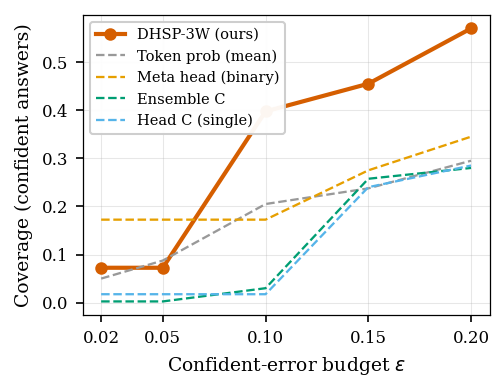

Figure 1 saved: fig_coverage.pdf


In [129]:

# FIGURE 1 — Coverage at matched confident-error budget


import matplotlib
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,   # embed TrueType fonts for IEEE
    "ps.fonttype": 42,
})

# Colorblind-safe palette (Okabe-Ito + extras)
palette = {
    "Token prob (mean)":            "#999999",
    "Token prob (min)":             "#bbbbbb",
    "Token prob (mean·min)":        "#dddddd",
    "Head C (single)":              "#56B4E9",
    "Ensemble C":                   "#009E73",
    "Meta head (binary)":           "#E69F00",
    "DHSP-3W (proposed)":           "#D55E00",
}

fig, ax = plt.subplots(figsize=(3.5, 2.6))

# Order in legend: DHSP-3W first, then strongest baselines, then weaker ones
order = ["DHSP-3W (proposed)",
         "Token prob (mean)",
         "Meta head (binary)",
         "Ensemble C",
         "Head C (single)"]

for name in order:
    if name not in results: continue
    row = results[name]
    covs = [c for c, _ in row]
    lw = 2.0 if "DHSP" in name else 1.1
    ls = "-o" if "DHSP" in name else "--"
    ms = 5.0 if "DHSP" in name else 4.0
    ax.plot(HARM_BUDGETS, covs, ls, lw=lw, markersize=ms,
            color=palette.get(name, "#333333"),
            label=name.replace(" (proposed)", " (ours)"))

ax.set_xlabel(r"Confident-error budget $\epsilon$")
ax.set_ylabel(r"Coverage (confident answers)")
ax.set_xticks(HARM_BUDGETS)
ax.set_xticklabels([f"{e:.2f}" for e in HARM_BUDGETS])
ax.grid(alpha=0.3, lw=0.5)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, framealpha=0.95)

plt.savefig("/kaggle/working/fig_coverage.pdf")
plt.savefig("/kaggle/working/fig_coverage.png", dpi=300)
plt.show()
print("Figure 1 saved: fig_coverage.pdf")

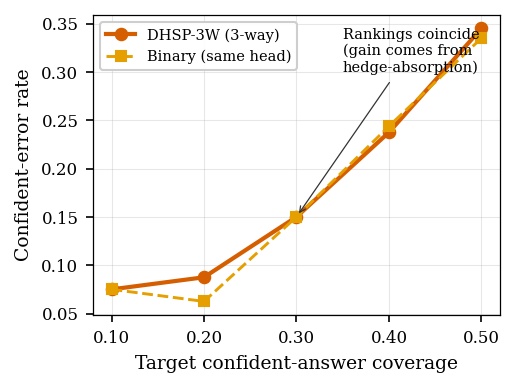

Figure 2 saved: fig_matched_cov.pdf


In [130]:

# FIGURE 2 — Matched-coverage diagnostic: 3W vs binary


fig, ax = plt.subplots(figsize=(3.5, 2.6))

c_3w = [matched_cov_ablation[c]["3w"] for c in COVS]
c_2w = [matched_cov_ablation[c]["2w"] for c in COVS]

ax.plot(COVS, c_3w, "-o", lw=2.0, markersize=5.5,
        color="#D55E00", label="DHSP-3W (3-way)")
ax.plot(COVS, c_2w, "--s", lw=1.4, markersize=4.5,
        color="#E69F00", label="Binary (same head)")

ax.set_xlabel("Target confident-answer coverage")
ax.set_ylabel("Confident-error rate")
ax.set_xticks(COVS)
ax.set_xticklabels([f"{c:.2f}" for c in COVS])
ax.grid(alpha=0.3, lw=0.5)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, framealpha=0.95)

# Annotate the overlap region — the point of the figure
ax.annotate("Rankings coincide\n(gain comes from\nhedge-absorption)",
            xy=(0.30, 0.150), xytext=(0.35, 0.30),
            fontsize=7, ha="left",
            arrowprops=dict(arrowstyle="->", lw=0.6, color="#333333"))

plt.savefig("/kaggle/working/fig_matched_cov.pdf")
plt.savefig("/kaggle/working/fig_matched_cov.png", dpi=300)
plt.show()
print("Figure 2 saved: fig_matched_cov.pdf")

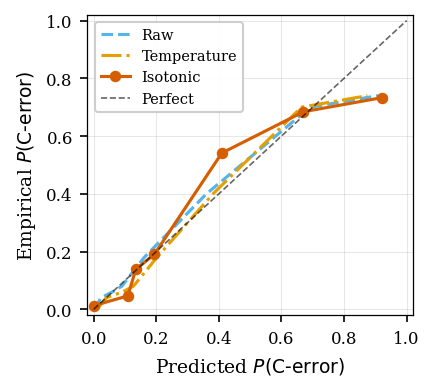

Figure 3 saved: fig_reliability.pdf


In [131]:

# FIGURE 3 — Reliability diagram of calibrated meta head


from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(2.8, 2.6))

y_true = np.array(c_flags)   # C-error flags on test

# Raw meta head, temperature-scaled, and calibrated
raw   = meta_test
temp  = meta_test_t
iso   = meta_test_i

for probs, name, color, ls in [
    (raw,  "Raw",        "#56B4E9", "--"),
    (temp, "Temperature","#E69F00", "-."),
    (iso,  "Isotonic",   "#D55E00", "-o"),
]:
    frac, mean_pred = calibration_curve(y_true, probs, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac, ls, lw=1.5, markersize=4.5,
            color=color, label=name)

ax.plot([0,1],[0,1], "k--", lw=0.8, alpha=0.6, label="Perfect")

ax.set_xlabel("Predicted $P(\\mathrm{C\\text{-}error})$")
ax.set_ylabel("Empirical $P(\\mathrm{C\\text{-}error})$")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3, lw=0.5)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, framealpha=0.95)

plt.savefig("/kaggle/working/fig_reliability.pdf")
plt.savefig("/kaggle/working/fig_reliability.png", dpi=300)
plt.show()
print("Figure 3 saved: fig_reliability.pdf")

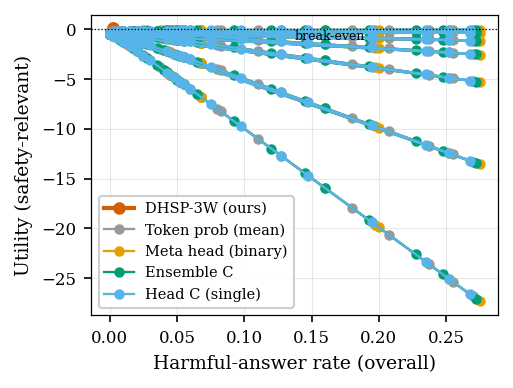

Figure 4 saved: fig_pareto.pdf


In [132]:

# FIGURE 4 — Utility vs harmful-answer rate (v2)


fig, ax = plt.subplots(figsize=(3.5, 2.6))

# Same palette as Figure 1 for consistency
palette_pareto = {
    "Token prob (mean)":            "#999999",
    "Token prob (min)":             "#bbbbbb",
    "Token prob (mean·min)":        "#dddddd",
    "Head C (single)":              "#56B4E9",
    "Ensemble C":                   "#009E73",
    "Meta head (binary)":           "#E69F00",
    "DHSP-3W (proposed)":           "#D55E00",
}

order_pareto = ["DHSP-3W (proposed)",
                "Token prob (mean)",
                "Meta head (binary)",
                "Ensemble C",
                "Head C (single)"]

for name in order_pareto:
    if name not in pareto: continue
    pts = pareto[name]
    xs, ys = [], []
    for p in pts:
        if isinstance(p, list):
            for pp in p:
                xs.append(pp[0]); ys.append(pp[2])   # index 2 = utility v2
        else:
            xs.append(p[0]); ys.append(p[2])
    lw = 2.0 if "DHSP" in name else 1.1
    ms = 5.0 if "DHSP" in name else 4.0
    ax.plot(xs, ys, "-o", lw=lw, markersize=ms,
            color=palette_pareto.get(name, "#333333"),
            label=name.replace(" (proposed)", " (ours)"))

ax.axhline(0.0, color="k", lw=0.6, ls=":")
ax.text(0.19, -0.03, "break-even", fontsize=6, color="k",
        ha="right", va="top")

ax.set_xlabel("Harmful-answer rate (overall)")
ax.set_ylabel("Utility (safety-relevant)")
ax.grid(alpha=0.3, lw=0.5)
ax.set_axisbelow(True)
ax.legend(loc="lower left", frameon=True, framealpha=0.95)

plt.savefig("/kaggle/working/fig_pareto.pdf")
plt.savefig("/kaggle/working/fig_pareto.png", dpi=300)
plt.show()
print("Figure 4 saved: fig_pareto.pdf")

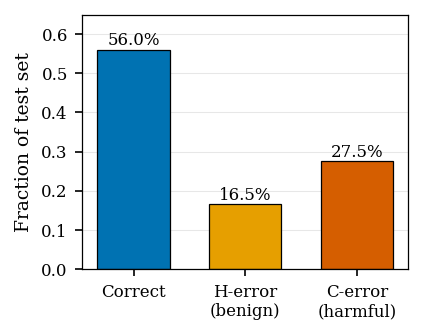

Figure 5 saved: fig_composition.pdf


In [133]:

# FIGURE 5 (optional) — Error composition on test set


fig, ax = plt.subplots(figsize=(2.8, 2.2))

labels = ["Correct", "H-error\n(benign)", "C-error\n(harmful)"]
values = [acc_rate, h_rate, c_rate]
colors = ["#0072B2", "#E69F00", "#D55E00"]

bars = ax.bar(labels, values, color=colors,
              edgecolor="black", linewidth=0.6, width=0.65)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012,
            f"{v*100:.1f}%", ha="center", fontsize=8)

ax.set_ylabel("Fraction of test set")
ax.set_ylim(0, 0.65)
ax.grid(alpha=0.3, lw=0.5, axis="y")
ax.set_axisbelow(True)

plt.savefig("/kaggle/working/fig_composition.pdf")
plt.savefig("/kaggle/working/fig_composition.png", dpi=300)
plt.show()
print("Figure 5 saved: fig_composition.pdf")

## contributions:

1. Error-type decomposition and confident-answer coverage. Correct / H-error / C-error. Coverage counts confident answers only; hedges are effective abstentions.

2. Three-way decision policy with a specific, falsifiable claim. Hedge-absorption expands coverage at fixed confident-error budget.

3. Isolation ablation. Same meta head, same calibration, only the decision layer differs. Shows three-way coverage dominates at ε ≥ 0.10 and confirms via matched-coverage analysis that risk ranking is not the source of the win.

4. Negative result at strict budgets. Binary policies win at ε ≤ 0.05 for a straightforward reason: hedge-absorption has nothing to absorb when the safe-answer set is already small.

5. Negative result on finite-sample certification. Clopper–Pearson LTT is infeasible at n_cal ≈ 287 for ε ≤ 0.10.